# MLP com `make_moons`: entendendo pesos, gradientes e backpropagation

## Objetivo

Este projeto tem como objetivo construir uma **MLP pequena em PyTorch** para estudar, de forma visual e matemática, como uma rede neural aprende.

O dataset escolhido é o **`make_moons`**, um problema de classificação binária com apenas **2 features**, o que permite acompanhar com clareza:

* os pesos e biases de cada camada;
* o forward pass;
* a função de ativação;
* a loss;
* os gradientes calculados pelo backpropagation;
* a atualização dos parâmetros pelo optimizer.

A ideia principal não é buscar a melhor performance possível, mas **entender o processo de treinamento de uma rede neural passo a passo**.

## Arquitetura inicial

Vamos utilizar uma MLP pequena:

```text
2 features
   ↓
Linear: 2 → 4
   ↓
ReLU
   ↓
Linear: 4 → 2
   ↓
ReLU
   ↓
Linear: 2 → 1
   ↓
classificação binária
```

Com poucos parâmetros, será possível inspecionar praticamente toda a rede durante o treinamento.


## IMPORTS

In [1]:
# ============================================================
# 0. IMPORTS
# ============================================================

# PyTorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Dataset artificial
from sklearn.datasets import make_moons

# Divisão treino / validação / teste
from sklearn.model_selection import train_test_split

# Visualização
import matplotlib.pyplot as plt

# NumPy
import numpy as np

## CONFIGS

In [2]:
# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

# Seed para reprodutibilidade
seed = 42

# Quantidade total de exemplos do dataset
n_samples = 500

# Ruído aplicado ao make_moons
# Quanto maior, mais difícil fica a separação das classes
noise = 0.15

# Quantidade de exemplos processados por atualização dos pesos
batch_size = 32

# Tamanho do passo utilizado pelo optimizer
learning_rate = 0.1

# Quantas vezes o modelo verá todo o dataset de treino
epochs = 150


# ============================================================
# 2. SEEDS
# ============================================================

# Controla aleatoriedade do PyTorch
torch.manual_seed(seed)

# Controla aleatoriedade do NumPy
np.random.seed(seed)


# ============================================================
# 3. DEVICE
# ============================================================

if torch.cuda.is_available():

    device = "cuda"

elif torch.backends.mps.is_available():

    # Mac Apple Silicon
    device = "mps"

else:

    device = "cpu"


# ============================================================
# 4. RESUMO DAS CONFIGURAÇÕES
# ============================================================

print("========== CONFIGURAÇÕES ==========")

print(f"Device:        {device}")
print(f"Seed:          {seed}")
print(f"N samples:     {n_samples}")
print(f"Noise:         {noise}")
print(f"Batch size:    {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs:        {epochs}")

========== CONFIGURAÇÕES ==========
Device:        mps
Seed:          42
N samples:     500
Noise:         0.15
Batch size:    32
Learning rate: 0.1
Epochs:        150


## IMPORT DATA e EDA

In [3]:
# ============================================================
# 2. IMPORTANDO / CRIANDO O DATASET
# ============================================================

# O make_moons cria um dataset artificial de classificação binária
#
# Ele retorna:
#
# X -> features
# y -> classe
#
# Como temos 2 features:
#
# X.shape = [n_samples, 2]
#
# E como é classificação binária:
#
# y contém 0 ou 1

X, y = make_moons(
    n_samples=n_samples,
    noise=noise,
    random_state=seed
)


print("Shape de X:")
print(X.shape)

print("\nShape de y:")
print(y.shape)

Shape de X:
(500, 2)

Shape de y:
(500,)


In [4]:
# ============================================================
# 3. DATAFRAME PARA EDA
# ============================================================

import pandas as pd


df = pd.DataFrame(
    X,
    columns=["x1", "x2"]
)

df["target"] = y


print("Primeiras linhas:")
display(df.head())

Primeiras linhas:


,x1,x2,target
0,0.830767,-0.372139,1
1,0.895032,0.858306,0
2,1.078857,-0.477753,1
3,-0.199521,1.006578,0
4,0.368137,1.238081,0


In [5]:
# ============================================================
# 4. INFORMAÇÕES GERAIS
# ============================================================

print("========== INFORMAÇÕES GERAIS ==========")

print("\nDimensão do dataset:")
print(df.shape)

print("\nTipos das colunas:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

print("\nEstatísticas descritivas:")
display(df.describe())

========== INFORMAÇÕES GERAIS ==========

Dimensão do dataset:
(500, 3)

Tipos das colunas:
x1        float64
x2        float64
target      int64
dtype: object

Valores nulos:
x1        0
x2        0
target    0
dtype: int64

Estatísticas descritivas:


,x1,x2,target
count,500.000000,500.000000,500.000000
mean,0.513609,0.254025,0.500000
std,0.883814,0.523742,0.500501
min,-1.343764,-0.859615,0.000000
25%,-0.102597,-0.203780,0.000000
50%,0.471290,0.273750,0.500000
75%,1.099789,0.675605,1.000000
max,2.327703,1.373444,1.000000


In [6]:
# ============================================================
# 5. DISTRIBUIÇÃO DAS CLASSES
# ============================================================

print("========== DISTRIBUIÇÃO DAS CLASSES ==========")

contagem_classes = df["target"].value_counts().sort_index()

print(contagem_classes)


print("\nProporção das classes:")

print(
    df["target"]
    .value_counts(normalize=True)
    .sort_index()
)

========== DISTRIBUIÇÃO DAS CLASSES ==========
target
0    250
1    250
Name: count, dtype: int64

Proporção das classes:
target
0    0.5
1    0.5
Name: proportion, dtype: float64


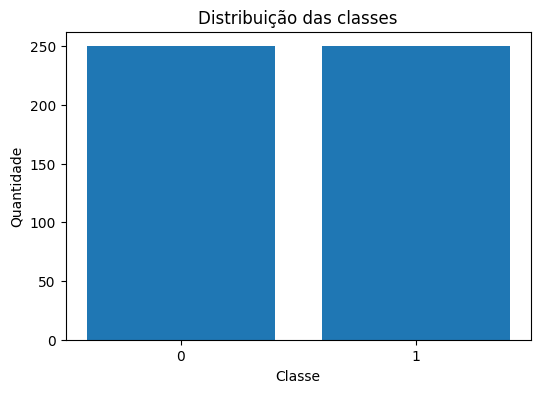

In [7]:
plt.figure(figsize=(6, 4))

plt.bar(
    contagem_classes.index.astype(str),
    contagem_classes.values
)

plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.title("Distribuição das classes")

plt.show()

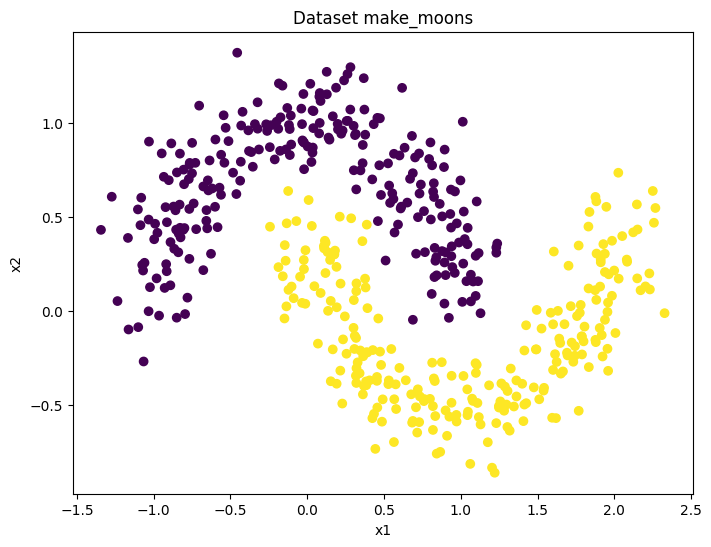

In [8]:
# ============================================================
# 6. VISUALIZAÇÃO DO DATASET
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["x1"],
    df["x2"],
    c=df["target"]
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Dataset make_moons")

plt.show()

## DIVISAO DATASET: TREINO, VALIAÇÃO, TESTE

In [9]:
# ============================================================
# 7. DIVISÃO TREINO / VALIDAÇÃO / TESTE
# ============================================================

# Vamos usar:
#
# 80% -> treino
# 10% -> validação
# 10% -> teste


# ============================================================
# PRIMEIRA DIVISÃO
# ============================================================

# Separamos 20% dos dados para:
#
# validação + teste

X_treino, X_temp, y_treino, y_temp = train_test_split(

    X,
    y,

    # 20% fica separado inicialmente
    test_size=0.20,

    # Mantém a mesma proporção das classes 0 e 1
    stratify=y,

    # Reprodutibilidade
    random_state=seed
)


# ============================================================
# SEGUNDA DIVISÃO
# ============================================================

# X_temp representa 20% do dataset original.
#
# Dividimos esse conjunto no meio:
#
# 10% validação
# 10% teste

X_validacao, X_teste, y_validacao, y_teste = train_test_split(

    X_temp,
    y_temp,

    # Metade dos 20% vai para teste
    test_size=0.50,

    stratify=y_temp,

    random_state=seed
)


# ============================================================
# VERIFICANDO OS TAMANHOS
# ============================================================

print("========== DIVISÃO DOS DADOS ==========")

print(f"Dataset total: {len(X)}")

print(
    f"\nTreino:     {len(X_treino)} "
    f"({len(X_treino) / len(X):.0%})"
)

print(
    f"Validação:  {len(X_validacao)} "
    f"({len(X_validacao) / len(X):.0%})"
)

print(
    f"Teste:      {len(X_teste)} "
    f"({len(X_teste) / len(X):.0%})"
)

========== DIVISÃO DOS DADOS ==========
Dataset total: 500

Treino:     400 (80%)
Validação:  50 (10%)
Teste:      50 (10%)


## PYTORCH

In [10]:
# ============================================================
# 8. CONVERTENDO OS DADOS PARA TENSORS
# ============================================================

# O scikit-learn retorna arrays NumPy.
#
# O PyTorch trabalha com torch.Tensor.
#
# Para as features X:
# usamos float32, que é o tipo padrão mais comum
# para treinamento de redes neurais.
#
# Para o target y:
# como depois vamos usar BCEWithLogitsLoss,
# também vamos usar float32.

X_treino_tensor = torch.tensor(
    X_treino,
    dtype=torch.float32
)

y_treino_tensor = torch.tensor(
    y_treino,
    dtype=torch.float32
)

X_validacao_tensor = torch.tensor(
    X_validacao,
    dtype=torch.float32
)

y_validacao_tensor = torch.tensor(
    y_validacao,
    dtype=torch.float32
)

X_teste_tensor = torch.tensor(
    X_teste,
    dtype=torch.float32
)

y_teste_tensor = torch.tensor(
    y_teste,
    dtype=torch.float32
)


# ============================================================
# 9. INSPECIONANDO OS TENSORS
# ============================================================

print("========== TENSORS ==========")

print("\nX treino:")
print("Shape:", X_treino_tensor.shape)
print("dtype:", X_treino_tensor.dtype)

print("\ny treino:")
print("Shape:", y_treino_tensor.shape)
print("dtype:", y_treino_tensor.dtype)

print("\nPrimeiros exemplos:")
print(X_treino_tensor[:5])

print("\nPrimeiros targets:")
print(y_treino_tensor[:5])

========== TENSORS ==========

X treino:
Shape: torch.Size([400, 2])
dtype: torch.float32

y treino:
Shape: torch.Size([400])
dtype: torch.float32

Primeiros exemplos:
tensor([[ 1.4265, -0.4899],
        [ 1.6756, -0.0700],
        [-0.9229,  0.5523],
        [-0.9190,  0.2493],
        [ 1.0469, -0.5355]])

Primeiros targets:
tensor([1., 1., 0., 0., 1.])


In [11]:
# ============================================================
# 10. TENSOR DATASETS
# ============================================================

# TensorDataset associa:
#
# X[i] <-> y[i]
#
# formando um dataset que o DataLoader consegue utilizar.

dataset_treino = TensorDataset(
    X_treino_tensor,
    y_treino_tensor
)

dataset_validacao = TensorDataset(
    X_validacao_tensor,
    y_validacao_tensor
)

dataset_teste = TensorDataset(
    X_teste_tensor,
    y_teste_tensor
)


print("\n========== DATASETS ==========")

print("Treino:", len(dataset_treino))
print("Validação:", len(dataset_validacao))
print("Teste:", len(dataset_teste))


========== DATASETS ==========
Treino: 400
Validação: 50
Teste: 50


In [12]:
# ============================================================
# 11. DATALOADERS
# ============================================================

loader_treino = DataLoader(

    dataset_treino,

    batch_size=batch_size,

    # Embaralha os exemplos a cada epoch
    shuffle=True
)


loader_validacao = DataLoader(

    dataset_validacao,

    batch_size=batch_size,

    shuffle=False
)


loader_teste = DataLoader(

    dataset_teste,

    batch_size=batch_size,

    shuffle=False
)

In [13]:
# ============================================================
# 12. ENTENDENDO UM BATCH
# ============================================================

X_batch, y_batch = next(iter(loader_treino))


print("\n========== BATCH ==========")

print("Shape de X:")
print(X_batch.shape)

print("\nShape de y:")
print(y_batch.shape)

print("\nX:")
print(X_batch)

print("\ny:")
print(y_batch)


========== BATCH ==========
Shape de X:
torch.Size([32, 2])

Shape de y:
torch.Size([32])

X:
tensor([[ 0.0200,  1.2083],
        [ 1.7898, -0.2307],
        [-0.7664,  0.7783],
        [ 1.8845,  0.3057],
        [ 0.8764, -0.2720],
        [ 0.4567,  1.0271],
        [-0.4832,  0.7355],
        [ 0.2567,  1.0106],
        [ 0.9319,  0.5159],
        [ 0.3035,  0.0583],
        [ 0.7666,  0.3130],
        [ 0.6179,  1.1867],
        [ 0.2621,  1.2601],
        [ 0.4058, -0.3685],
        [-0.8055,  0.7518],
        [ 1.2644, -0.3848],
        [ 0.1661, -0.2038],
        [-0.5842,  0.4459],
        [ 0.3021,  0.9846],
        [ 1.4081, -0.5853],
        [ 0.9011, -0.5284],
        [ 0.3111,  0.9354],
        [ 0.2642,  1.0113],
        [-0.9229,  0.5523],
        [-0.1738,  1.0301],
        [-0.3837,  0.9606],
        [ 1.1844, -0.3949],
        [ 0.4348, -0.5464],
        [ 1.6015, -0.0705],
        [ 0.6877, -0.5842],
        [ 0.3775,  0.9376],
        [ 1.2776, -0.5105]])

y:
tens

In [14]:
# ============================================================
# 13. CONSTRUINDO A MLP
# ============================================================

class MLP(nn.Module):

    def __init__(self):

        # Inicializa a classe base nn.Module
        super().__init__()
        # 2 -> 4
        self.linear1 = nn.Linear(
            in_features=2,
            out_features=4
        )
        self.relu1 = nn.LeakyReLU(negative_slope=0.01)


        # 4 -> 2
        self.linear2 = nn.Linear(
            in_features=4,
            out_features=2
        )
        self.relu2 = nn.LeakyReLU(negative_slope=0.01)

        # 2 -> 1
        self.output = nn.Linear(
            in_features=2,
            out_features=1
        )


    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        x = self.linear1(x)
        x = self.relu1(x)

        x = self.linear2(x)
        embedding = self.relu2(x)

        logit = self.output(embedding)

        return logit

    def get_embedding(self, x):

        # Executa a rede somente até
        # a última camada escondida.

        x = self.linear1(x)

        x = self.relu1(x)

        x = self.linear2(x)

        embedding = self.relu2(x)

        return embedding

In [15]:
# ============================================================
# 14. CRIANDO O MODELO
# ============================================================

modelo = MLP().to(device)


print("========== ARQUITETURA ==========")

print(modelo)

========== ARQUITETURA ==========
MLP(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (relu1): LeakyReLU(negative_slope=0.01)
  (linear2): Linear(in_features=4, out_features=2, bias=True)
  (relu2): LeakyReLU(negative_slope=0.01)
  (output): Linear(in_features=2, out_features=1, bias=True)
)


## Arquitetura Matemática da MLP

A rede utilizada possui a arquitetura:

**2 → 4 → 2 → 1**

- 2 features de entrada
- 4 neurônios na primeira camada escondida
- 2 neurônios na segunda camada escondida
- 1 neurônio de saída

---

### Entrada

Cada exemplo possui duas features:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

Portanto:

$$
x \in \mathbb{R}^2
$$

---

### Camada 1

A primeira camada realiza:

$$
z_1 = W_1x + b_1
$$

onde:

$$
W_1 \in \mathbb{R}^{4 \times 2}
$$

$$
b_1 \in \mathbb{R}^{4}
$$

Depois aplicamos ReLU:

$$
h_1 = ReLU(z_1)
$$

A saída dessa camada possui 4 dimensões:

$$
h_1 \in \mathbb{R}^{4}
$$

---

### Camada 2 — Embedding

A segunda camada realiza:

$$
z_2 = W_2h_1 + b_2
$$

onde:

$$
W_2 \in \mathbb{R}^{2 \times 4}
$$

$$
b_2 \in \mathbb{R}^{2}
$$

Aplicamos novamente ReLU:

$$
e = ReLU(z_2)
$$

O vetor:

$$
e \in \mathbb{R}^{2}
$$

será considerado o **embedding aprendido pela rede**.

---

### Camada de saída

A última camada recebe o embedding e produz um único valor:

$$
z = W_3e + b_3
$$

onde:

$$
W_3 \in \mathbb{R}^{1 \times 2}
$$

O valor $z$ é chamado de **logit**.

Para convertê-lo em probabilidade da classe 1:

$$
\hat{y} = \sigma(z)
$$

onde:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

---


$$
\hat{y}
=
\sigma
\left(
W_3\,
ReLU
\left(
W_2\,
ReLU
\left(
W_1x+b_1
\right)
+b_2
\right)
+b_3
\right)
$$

![Texto alternativo](img/img.png)

## Loss e Optimizer

In [16]:
# ============================================================
# 15. LOSS E OPTIMIZER
# ============================================================

# Classificação binária
#
# O modelo retorna um único logit.
#
# BCEWithLogitsLoss faz internamente:
#
# logit
#   ↓
# sigmoid
#   ↓
# Binary Cross-Entropy

loss_fn = nn.BCEWithLogitsLoss()


# Para fins didáticos vamos usar SGD,
# pois a atualização é diretamente:
#
# parametro_novo =
# parametro_antigo - learning_rate * gradiente

optimizer = torch.optim.SGD(
    modelo.parameters(),
    lr=learning_rate
)


print("Loss:")
print(loss_fn)

print("\nOptimizer:")
print(optimizer)

Loss:
BCEWithLogitsLoss()

Optimizer:
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [17]:
# ============================================================
# FUNÇÃO PARA SALVAR TODOS OS PARÂMETROS
# ============================================================

def salvar_parametros(modelo):

    parametros = {}

    for nome, parametro in modelo.named_parameters():

        parametros[nome] = (
            parametro
            .detach()
            .clone()
            .cpu()
        )

    return parametros

## Fazendo um batch para ver os parametros sendo atualizados

In [18]:
# ============================================================
# 16. UM PASSO DE TREINAMENTO
# ============================================================

modelo.train()


# Pegamos apenas um batch
X_batch, y_batch = next(iter(loader_treino))


# Move para device
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)


# BCEWithLogitsLoss espera que target
# tenha o mesmo shape dos logits:
#
# logits -> [32, 1]
# y      -> [32, 1]

y_batch = y_batch.unsqueeze(1)


print("Shape X:")
print(X_batch.shape)

print("\nShape y:")
print(y_batch.shape)

Shape X:
torch.Size([32, 2])

Shape y:
torch.Size([32, 1])


In [19]:
# ============================================================
# PARÂMETROS ANTES DO TREINAMENTO
# ============================================================

parametros_antes = salvar_parametros(modelo)


print("\n========== PARÂMETROS ANTES ==========")


for nome, valores in parametros_antes.items():

    print(f"\n{nome}")

    print(valores)


========== PARÂMETROS ANTES ==========

linear1.weight
tensor([[-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323]])

linear1.bias
tensor([ 0.5224,  0.0958,  0.3410, -0.0998])

linear2.weight
tensor([[ 0.3854,  0.0739, -0.2334,  0.1274],
        [-0.2304, -0.0586, -0.2031,  0.3317]])

linear2.bias
tensor([-0.3947, -0.2305])

output.weight
tensor([[-0.1997, -0.4252]])

output.bias
tensor([0.0667])


In [20]:
# ============================================================
# FORWARD
# ============================================================

logits = modelo(X_batch)


print("\n========== FORWARD ==========")

print("Primeiros logits:")

print(
    logits[:5]
    .detach()
    .cpu()
)


========== FORWARD ==========
Primeiros logits:
tensor([[0.0689],
        [0.0687],
        [0.0686],
        [0.0685],
        [0.0692]])


Conceitualmente:

X→W
1
	​

X+b
1
	​

→ReLU→W
2
	​

h
1
	​

+b
2
	​

→ReLU→W
3
	​

e+b
3
	​

→z

In [21]:
# ============================================================
# LOSS
# ============================================================

loss = loss_fn(
    logits,
    y_batch
)


print("\n========== LOSS ==========")

print(
    loss.item()
)


========== LOSS ==========
0.6957435011863708


In [22]:
# ============================================================
# ZERANDO GRADIENTES
# ============================================================

optimizer.zero_grad()

In [23]:
# ============================================================
# BACKPROPAGATION
# ============================================================

loss.backward() #Agora todos os 25 parâmetros possuem gradientes.

In [24]:
print("\n========== GRADIENTES ==========")


for nome, parametro in modelo.named_parameters():

    print(f"\n∂Loss/∂{nome}")

    print(
        parametro.grad
        .detach()
        .cpu()
    )


========== GRADIENTES ==========

∂Loss/∂linear1.weight
tensor([[-4.8909e-05,  5.4543e-05],
        [-4.8920e-06,  1.7333e-05],
        [-2.1995e-04,  1.7630e-04],
        [ 2.6030e-04, -2.4473e-04]])

∂Loss/∂linear1.bias
tensor([ 1.0171e-05,  1.9798e-05, -1.4827e-04,  1.0931e-04])

∂Loss/∂linear2.weight
tensor([[-0.0002, -0.0002,  0.0004,  0.0001],
        [-0.0004, -0.0005,  0.0009,  0.0003]])

∂Loss/∂linear2.bias
tensor([-9.6784e-05, -2.0609e-04])

∂Loss/∂output.weight
tensor([[ 0.0007, -0.0002]])

∂Loss/∂output.bias
tensor([0.0485])


In [25]:
gradientes = {}


for nome, parametro in modelo.named_parameters():

    gradientes[nome] = (
        parametro.grad
        .detach()
        .clone()
        .cpu()
    )

In [26]:
# ============================================================
# UPDATE 10. Atualizando TODOS os parâmetros
# ============================================================

optimizer.step()

In [27]:
# 11. Salvando parâmetros depois
parametros_depois = salvar_parametros(modelo)

In [28]:
# ============================================================
# COMPARANDO TODOS OS PARÂMETROS
# ============================================================

for nome in parametros_antes:

    print("\n")
    print("=" * 60)
    print(nome)
    print("=" * 60)


    print("\nANTES:")

    print(
        parametros_antes[nome]
    )


    print("\nGRADIENTE:")

    print(
        gradientes[nome]
    )


    print("\nDEPOIS:")

    print(
        parametros_depois[nome]
    )


    print("\nALTERAÇÃO:")

    print(
        parametros_depois[nome]
        -
        parametros_antes[nome]
    )



linear1.weight

ANTES:
tensor([[-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323]])

GRADIENTE:
tensor([[-4.8909e-05,  5.4543e-05],
        [-4.8920e-06,  1.7333e-05],
        [-2.1995e-04,  1.7630e-04],
        [ 2.6030e-04, -2.4473e-04]])

DEPOIS:
tensor([[-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6234, -0.5188],
        [ 0.6146,  0.1324]])

ALTERAÇÃO:
tensor([[ 4.8876e-06, -5.4538e-06],
        [ 4.7684e-07, -1.7285e-06],
        [ 2.1994e-05, -1.7643e-05],
        [-2.6047e-05,  2.4468e-05]])


linear1.bias

ANTES:
tensor([ 0.5224,  0.0958,  0.3410, -0.0998])

GRADIENTE:
tensor([ 1.0171e-05,  1.9798e-05, -1.4827e-04,  1.0931e-04])

DEPOIS:
tensor([ 0.5224,  0.0958,  0.3410, -0.0998])

ALTERAÇÃO:
tensor([-1.0133e-06, -1.9819e-06,  1.4842e-05, -1.0930e-05])


linear2.weight

ANTES:
tensor([[ 0.3854,  0.0739, -0.2334,  0.1274],
        [-0.2304, -0.0586, -0.2031,  0.3317]])

GRADIENTE:
tensor([[-0.0002, -0.0002,  

In [29]:
import pandas as pd


linhas = []


for nome in parametros_antes:

    # transforma as matrizes em vetores
    antes_flat = parametros_antes[nome].flatten()

    grad_flat = gradientes[nome].flatten()

    depois_flat = parametros_depois[nome].flatten()


    for i in range(len(antes_flat)):

        antes = antes_flat[i].item()

        grad = grad_flat[i].item()

        depois = depois_flat[i].item()


        linhas.append({

            "parametro": nome,

            "indice": i,

            "antes": antes,

            "gradiente": grad,

            "depois": depois,

            "alteracao": depois - antes
        })


df_parametros = pd.DataFrame(linhas)


display(df_parametros)

,parametro,indice,antes,gradiente,depois,alteracao
0,linear1.weight,0,-0.154930,-0.000049,-0.154925,4.887581e-06
1,linear1.weight,1,0.142688,0.000055,0.142682,-5.453825e-06
2,linear1.weight,2,-0.344258,-0.000005,-0.344258,4.768372e-07
3,linear1.weight,3,0.415272,0.000017,0.415270,-1.728535e-06
4,linear1.weight,4,0.623345,-0.000220,0.623367,2.199411e-05
5,linear1.weight,5,-0.518753,0.000176,-0.518771,-1.764297e-05
6,linear1.weight,6,0.614614,0.000260,0.614588,-2.604723e-05
7,linear1.weight,7,0.132342,-0.000245,0.132366,2.446771e-05
8,linear1.bias,0,0.522417,0.000010,0.522416,-1.013279e-06
9,linear1.bias,1,0.095764,0.000020,0.095762,-1.981854e-06


## Treinando o modelo na vera

In [30]:
# ============================================================
# HISTÓRICOS
# ============================================================

historico_loss_treino = []

historico_loss_validacao = []

historico_parametros = []

In [31]:
def salvar_parametros(modelo, epoca):

    parametros_epoca = {
        "epoca": epoca
    }


    for nome, parametro in modelo.named_parameters():

        # Transformamos matriz/vetor em vetor único
        valores = (
            parametro
            .detach()
            .cpu()
            .flatten()
        )


        # Salva cada parâmetro individualmente
        for i, valor in enumerate(valores):

            parametros_epoca[
                f"{nome}_{i}"
            ] = valor.item()


    return parametros_epoca

In [32]:
modelo.eval()

with torch.no_grad():

    X_temp = X_treino_tensor.to(device)

    # Antes da ReLU
    z1 = modelo.linear1(X_temp)

    # Depois da ReLU
    h1 = modelo.relu1(z1)


print("Percentual de ativações positivas por neurônio:")

print(
    (h1 > 0)
    .float()
    .mean(dim=0)
    .cpu()
)

Percentual de ativações positivas por neurônio:
tensor([1.0000, 0.5150, 0.6850, 0.7000])


In [33]:
# ============================================================
# DIAGNÓSTICO DO TREINAMENTO
# ============================================================

modelo.train()

X_batch, y_batch = next(iter(loader_treino))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device).unsqueeze(1)


# Zera os gradientes
optimizer.zero_grad()


# Forward
logits = modelo(X_batch)


# Loss
loss = loss_fn(logits, y_batch)


# Backpropagation
loss.backward()


print("Loss:")
print(loss.item())


# ============================================================
# GRADIENTES
# ============================================================

print("\nGradiente máximo de cada parâmetro:")

for nome, parametro in modelo.named_parameters():

    print(
        nome,
        "->",
        parametro.grad.abs().max().item()
    )


# ============================================================
# LOGITS
# ============================================================

print("\nDesvio padrão dos logits:")
print(logits.detach().std().item())


print("\nPrimeiros 10 logits:")
print(
    logits[:10]
    .detach()
    .cpu()
    .flatten()
)

Loss:
0.6935698986053467

Gradiente máximo de cada parâmetro:
linear1.weight -> 0.00022312179498840123
linear1.bias -> 0.0001698091218713671
linear2.weight -> 0.0006727277068421245
linear2.bias -> 6.797492096666247e-05
output.weight -> 0.0005180242005735636
output.bias -> 0.015988720580935478

Desvio padrão dos logits:
0.000361297425115481

Primeiros 10 logits:
tensor([0.0638, 0.0646, 0.0642, 0.0642, 0.0639, 0.0639, 0.0633, 0.0635, 0.0639,
        0.0646])


In [34]:
# ============================================================
# TREINAMENTO
# ============================================================

for epoca in range(epochs):


    # ========================================================
    # TREINO
    # ========================================================

    modelo.train()

    loss_total_treino = 0


    for X_batch, y_batch in loader_treino:

        # Move dados para device
        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)


        # BCEWithLogitsLoss precisa:
        #
        # logits -> [batch, 1]
        # target -> [batch, 1]

        y_batch = y_batch.unsqueeze(1)


        # ----------------------------------------------------
        # 1. Zerar gradientes
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # 2. Forward
        # ----------------------------------------------------

        logits = modelo(X_batch)


        # ----------------------------------------------------
        # 3. Loss
        # ----------------------------------------------------

        loss = loss_fn(
            logits,
            y_batch
        )


        # ----------------------------------------------------
        # 4. Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # 5. Atualizar pesos
        # ----------------------------------------------------

        optimizer.step()


        # Somamos a loss do batch
        loss_total_treino += loss.item()


    # Loss média dos batches
    loss_media_treino = (
        loss_total_treino
        /
        len(loader_treino)
    )


    # ========================================================
    # VALIDAÇÃO
    # ========================================================

    modelo.eval()

    loss_total_validacao = 0


    # Não precisamos calcular gradientes
    with torch.no_grad():

        for X_batch, y_batch in loader_validacao:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            y_batch = y_batch.unsqueeze(1)


            # Forward
            logits = modelo(X_batch)


            # Loss
            loss = loss_fn(
                logits,
                y_batch
            )


            loss_total_validacao += loss.item()


    loss_media_validacao = (
        loss_total_validacao
        /
        len(loader_validacao)
    )


    # ========================================================
    # SALVAR HISTÓRICO
    # ========================================================

    historico_loss_treino.append(
        loss_media_treino
    )

    historico_loss_validacao.append(
        loss_media_validacao
    )


    # Salva os 25 parâmetros dessa época
    historico_parametros.append(
        salvar_parametros(
            modelo,
            epoca + 1
        )
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Época {epoca+1:3d}/{epochs} | "
        f"Train Loss: {loss_media_treino:.6f} | "
        f"Validation Loss: {loss_media_validacao:.6f}"
    )

Época   1/150 | Train Loss: 0.693730 | Validation Loss: 0.692750
Época   2/150 | Train Loss: 0.693447 | Validation Loss: 0.692777
Época   3/150 | Train Loss: 0.693603 | Validation Loss: 0.692836
Época   4/150 | Train Loss: 0.693304 | Validation Loss: 0.692862
Época   5/150 | Train Loss: 0.693195 | Validation Loss: 0.692923
Época   6/150 | Train Loss: 0.693175 | Validation Loss: 0.692951
Época   7/150 | Train Loss: 0.693307 | Validation Loss: 0.693010
Época   8/150 | Train Loss: 0.693191 | Validation Loss: 0.693118
Época   9/150 | Train Loss: 0.693594 | Validation Loss: 0.692876
Época  10/150 | Train Loss: 0.693268 | Validation Loss: 0.692901
Época  11/150 | Train Loss: 0.693173 | Validation Loss: 0.692961
Época  12/150 | Train Loss: 0.693393 | Validation Loss: 0.692900
Época  13/150 | Train Loss: 0.693181 | Validation Loss: 0.692903
Época  14/150 | Train Loss: 0.693502 | Validation Loss: 0.692864
Época  15/150 | Train Loss: 0.693299 | Validation Loss: 0.692869
Época  16/150 | Train Los

In [35]:
df_historico_parametros = pd.DataFrame(
    historico_parametros
)

display(
    df_historico_parametros.head()
)

,epoca,linear1.weight_0,linear1.weight_1,linear1.weight_2,linear1.weight_3,linear1.weight_4,linear1.weight_5,linear1.weight_6,linear1.weight_7,linear1.bias_0,...,linear2.weight_3,linear2.weight_4,linear2.weight_5,linear2.weight_6,linear2.weight_7,linear2.bias_0,linear2.bias_1,output.weight_0,output.weight_1,output.bias_0
0,1,-0.154860,0.142628,-0.344251,0.415251,0.623649,-0.518920,0.614245,0.132653,0.522411,...,0.127245,-0.229912,-0.058068,-0.204247,0.331252,-0.394631,-0.230391,-0.200587,-0.424998,0.039867
1,2,-0.154797,0.142575,-0.344246,0.415233,0.623944,-0.519072,0.613890,0.132938,0.522409,...,0.127046,-0.229526,-0.057564,-0.205355,0.330831,-0.394611,-0.230349,-0.201472,-0.424904,0.029883
2,3,-0.154737,0.142525,-0.344240,0.415216,0.624232,-0.519221,0.613544,0.133220,0.522407,...,0.126853,-0.229142,-0.057065,-0.206441,0.330424,-0.394589,-0.230301,-0.202342,-0.424813,0.018731
3,4,-0.154678,0.142476,-0.344235,0.415199,0.624524,-0.519376,0.613197,0.133512,0.522406,...,0.126659,-0.228774,-0.056572,-0.207546,0.330019,-0.394581,-0.230285,-0.203239,-0.424763,0.014834
4,5,-0.154621,0.142428,-0.344230,0.415183,0.624821,-0.519534,0.612845,0.133805,0.522405,...,0.126462,-0.228397,-0.056075,-0.208657,0.329608,-0.394566,-0.230254,-0.204136,-0.424703,0.007663


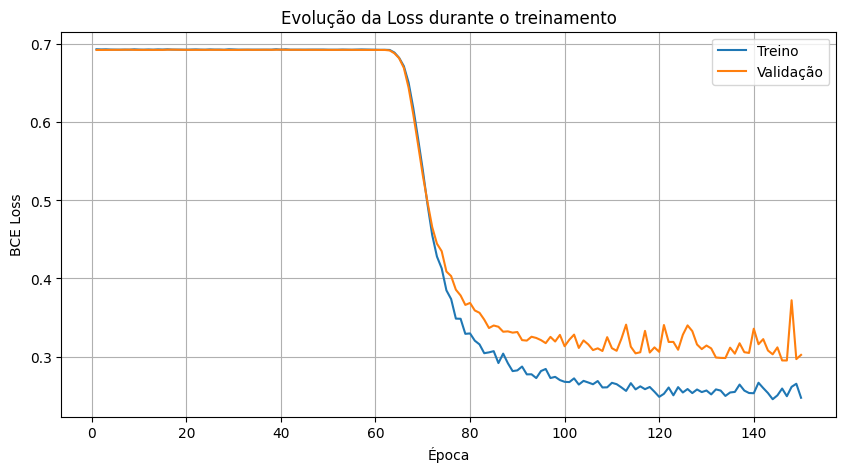

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, epochs + 1),
    historico_loss_treino,
    label="Treino"
)

plt.plot(
    range(1, epochs + 1),
    historico_loss_validacao,
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("BCE Loss")

plt.title("Evolução da Loss durante o treinamento")

plt.legend()
plt.grid()

plt.show()

In [46]:
# ============================================================
# AVALIAÇÃO NO DATASET DE TESTE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# Coloca o modelo em modo de avaliação
modelo.eval()


# Vamos guardar:
#
# valores verdadeiros
# probabilidades previstas
# classes previstas

y_true = []
y_prob = []
y_pred = []


loss_total_teste = 0


# Não precisamos calcular gradientes
with torch.no_grad():

    for X_batch, y_batch in loader_teste:

        # Move para o device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        # ====================================================
        # FORWARD
        # ====================================================

        logits = modelo(X_batch)

        # logits:
        #
        # [batch, 1]


        # Ajustamos o target para o mesmo formato
        y_batch_loss = y_batch.unsqueeze(1)


        # ====================================================
        # TEST LOSS
        # ====================================================

        loss = loss_fn(
            logits,
            y_batch_loss
        )

        loss_total_teste += loss.item()


        # ====================================================
        # LOGIT -> PROBABILIDADE
        # ====================================================

        probabilidades = torch.sigmoid(logits)


        # ====================================================
        # PROBABILIDADE -> CLASSE
        # ====================================================
        #
        # prob >= 0.5 -> classe 1
        # prob <  0.5 -> classe 0

        predicoes = (
            probabilidades >= 0.5
        ).int()


        # ====================================================
        # SALVAR RESULTADOS
        # ====================================================

        y_true.extend(
            y_batch.cpu().numpy()
        )

        y_prob.extend(
            probabilidades
            .cpu()
            .numpy()
            .flatten()
        )

        y_pred.extend(
            predicoes
            .cpu()
            .numpy()
            .flatten()
        )


# ============================================================
# LOSS MÉDIA DE TESTE
# ============================================================

loss_teste = (
    loss_total_teste
    /
    len(loader_teste)
)

In [47]:
# ============================================================
# MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

roc_auc = roc_auc_score(
    y_true,
    y_prob
)

In [48]:
print("=" * 40)
print("RESULTADOS NO DATASET DE TESTE")
print("=" * 40)

print(f"Test Loss : {loss_teste:.4f}")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-score  : {f1:.4f}")

print(f"ROC-AUC   : {roc_auc:.4f}")

RESULTADOS NO DATASET DE TESTE
Test Loss : 0.1905
Accuracy  : 0.8800
Precision : 0.8800
Recall    : 0.8800
F1-score  : 0.8800
ROC-AUC   : 0.9856


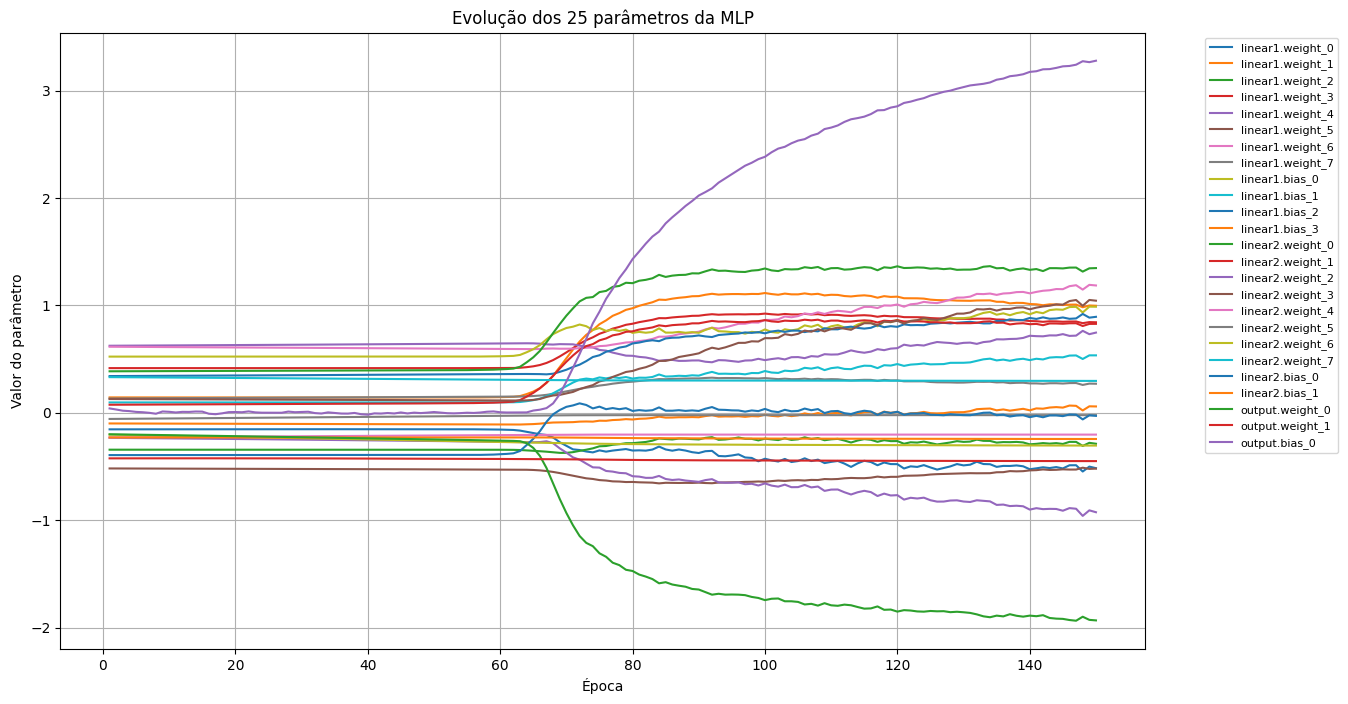

In [37]:
# ============================================================
# EVOLUÇÃO DOS 25 PARÂMETROS
# ============================================================

plt.figure(figsize=(14, 8))


# Todas as colunas, exceto "epoca"
colunas_parametros = [
    coluna
    for coluna in df_historico_parametros.columns
    if coluna != "epoca"
]


# Uma linha para cada parâmetro
for coluna in colunas_parametros:

    plt.plot(
        df_historico_parametros["epoca"],
        df_historico_parametros[coluna],
        label=coluna
    )


plt.xlabel("Época")

plt.ylabel("Valor do parâmetro")

plt.title(
    "Evolução dos 25 parâmetros da MLP"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid()

plt.show()

In [38]:
# ============================================================
# MUDANÇA TOTAL DOS PARÂMETROS
# ============================================================

mudancas = []


for coluna in colunas_parametros:

    valor_inicial = (
        df_historico_parametros[coluna]
        .iloc[0]
    )

    valor_final = (
        df_historico_parametros[coluna]
        .iloc[-1]
    )


    mudancas.append({

        "parametro": coluna,

        "inicial": valor_inicial,

        "final": valor_final,

        "mudanca": valor_final - valor_inicial,

        "mudanca_absoluta": abs(
            valor_final - valor_inicial
        )
    })


df_mudancas = pd.DataFrame(mudancas)


# Ordena pelos parâmetros que mais mudaram
df_mudancas = df_mudancas.sort_values(
    "mudanca_absoluta",
    ascending=False
)


display(df_mudancas)

,parametro,inicial,final,mudanca,mudanca_absoluta
24,output.bias_0,0.039867,3.277445,3.237578,3.237578
22,output.weight_0,-0.200587,-1.933756,-1.733169,1.733169
12,linear2.weight_0,0.385658,1.346640,0.960983,0.960983
15,linear2.weight_3,0.127245,1.043133,0.915887,0.915887
1,linear1.weight_1,0.142628,0.995745,0.853118,0.853118
13,linear2.weight_1,0.074172,0.827425,0.753253,0.753253
14,linear2.weight_2,-0.233969,-0.926590,-0.692621,0.692621
6,linear1.weight_6,0.614245,1.184890,0.570645,0.570645
10,linear1.bias_2,0.341222,0.892809,0.551587,0.551587
8,linear1.bias_0,0.522411,0.986909,0.464497,0.464497


## Analise dos enbeddings

In [39]:
# ============================================================
# RECRIANDO O MODELO ANTES DO TREINAMENTO
# ============================================================

torch.manual_seed(42)

modelo_inicial = MLP().to(device)

modelo_inicial.eval()
modelo.eval()

MLP(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (relu1): LeakyReLU(negative_slope=0.01)
  (linear2): Linear(in_features=4, out_features=2, bias=True)
  (relu2): LeakyReLU(negative_slope=0.01)
  (output): Linear(in_features=2, out_features=1, bias=True)
)

In [40]:
# ============================================================
# GERANDO OS EMBEDDINGS
# ============================================================

X_plot = X_treino_tensor.to(device)

y_plot = y_treino_tensor.cpu().numpy()


with torch.no_grad():

    # Embedding antes do treinamento
    embedding_inicial = (
        modelo_inicial
        .get_embedding(X_plot)
        .cpu()
        .numpy()
    )


    # Embedding depois do treinamento
    embedding_final = (
        modelo
        .get_embedding(X_plot)
        .cpu()
        .numpy()
    )

In [41]:
print("Shape do embedding inicial:")
print(embedding_inicial.shape)

print("\nShape do embedding final:")
print(embedding_final.shape)

Shape do embedding inicial:
(400, 2)

Shape do embedding final:
(400, 2)


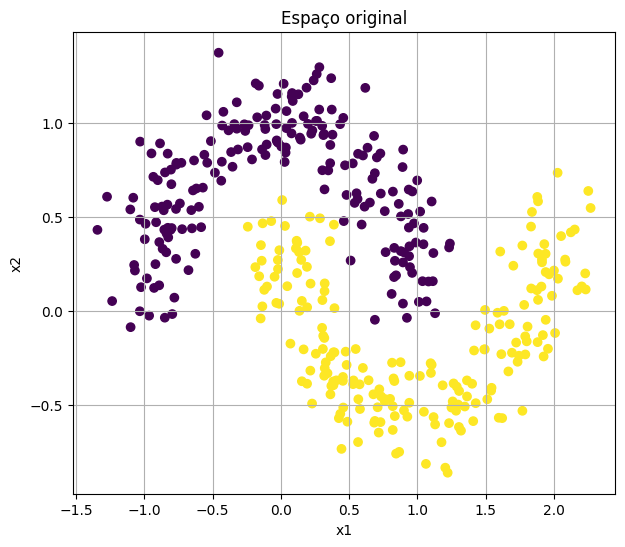

In [42]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X_treino[:, 0],
    X_treino[:, 1],
    c=y_treino
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Espaço original")

plt.grid()

plt.show()

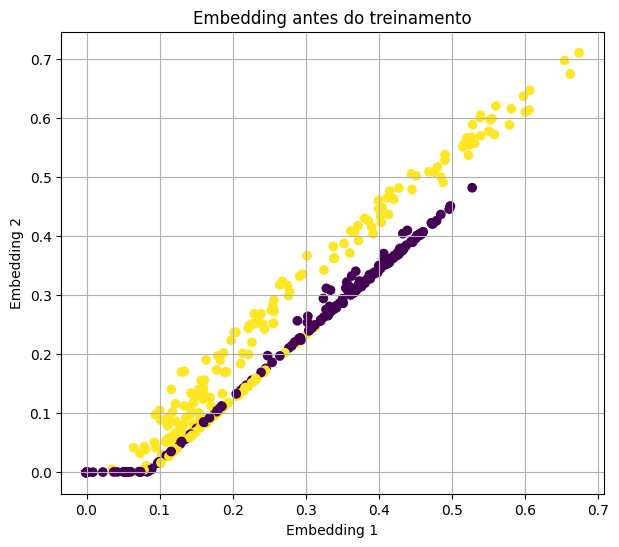

In [43]:
plt.figure(figsize=(7, 6))

plt.scatter(
    embedding_inicial[:, 0],
    embedding_inicial[:, 1],
    c=y_plot
)

plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")

plt.title("Embedding antes do treinamento")

plt.grid()

plt.show()

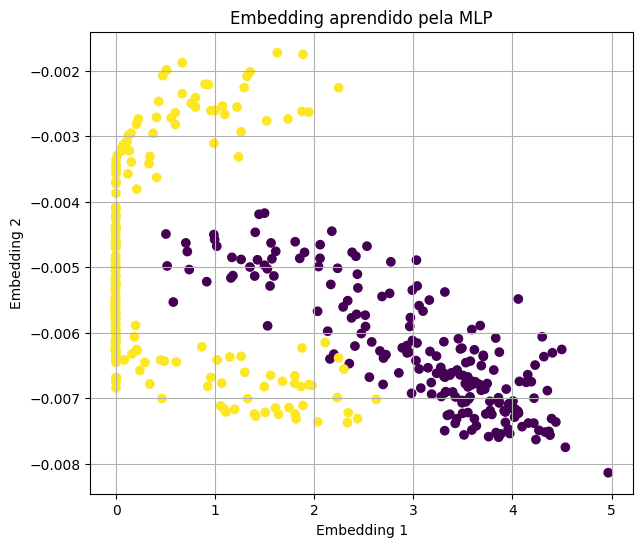

In [44]:
plt.figure(figsize=(7, 6))

plt.scatter(
    embedding_final[:, 0],
    embedding_final[:, 1],
    c=y_plot
)

plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")

plt.title("Embedding aprendido pela MLP")

plt.grid()

plt.show()